In [1]:
import numpy as np
import pandas as pd
import scipy, sklearn, statsmodels

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("scipy", scipy.__version__)
print("sklearn", sklearn.__version__)
print("statsmodels", statsmodels.__version__)

np.random.seed(42)
print("Setup OK")

numpy 2.1.3
pandas 2.2.3
scipy 1.16.3
sklearn 1.6.1
statsmodels 0.15.0
Setup OK


In [2]:
n_samples = 300
n_snps = 200

# each SNP gets its own minor allele frequency (MAF) between 5% and 50%
maf = np.random.uniform(0.05, 0.5, size=n_snps)

# genotype = number of minor alleles (0, 1 or 2), drawn from a binomial with 2 trials
genotypes = np.random.binomial(2, maf, size=(n_samples, n_snps))

snp_names = [f"snp_{i:03d}" for i in range(n_snps)]
sample_ids = [f"S{i:03d}" for i in range(n_samples)]
geno = pd.DataFrame(genotypes, index=sample_ids, columns=snp_names)

print(geno.shape)
print(geno.iloc[:5, :5])
print("Observed allele freq (first 5):", (geno.mean() / 2).head().round(3).values)
print("True MAF (first 5):", maf[:5].round(3))

(300, 200)
      snp_000  snp_001  snp_002  snp_003  snp_004
S000        1        0        0        2        0
S001        0        2        1        1        0
S002        0        1        0        0        0
S003        1        0        1        1        0
S004        0        1        2        1        1
Observed allele freq (first 5): [0.217 0.447 0.398 0.307 0.137]
True MAF (first 5): [0.219 0.478 0.379 0.319 0.12 ]


In [3]:
# Clinical / demographic variables
age = np.random.normal(45, 12, size=n_samples).clip(18, 80).round(1)
sex = np.random.binomial(1, 0.5, size=n_samples)  # 0 = female, 1 = male
bmi = np.random.normal(26, 4, size=n_samples).clip(16, 45).round(1)

# Baseline LDL cholesterol (mg/dL), before dietary restriction
baseline_ldl = np.random.normal(140, 25, size=n_samples).clip(60, 250).round(1)

clinical = pd.DataFrame({
    "age": age,
    "sex": sex,
    "bmi": bmi,
    "baseline_ldl": baseline_ldl
}, index=sample_ids)

print(clinical.shape)
print(clinical.head())
print(clinical.describe().round(2))

(300, 4)
       age  sex   bmi  baseline_ldl
S000  53.4    0  16.0         124.9
S001  44.4    0  29.1         129.3
S002  42.0    1  26.9         147.8
S003  30.9    1  28.7         153.7
S004  47.5    0  23.9         149.4
          age     sex     bmi  baseline_ldl
count  300.00  300.00  300.00        300.00
mean    45.74    0.51   25.80        137.72
std     12.13    0.50    4.10         25.85
min     18.00    0.00   16.00         78.10
25%     37.70    0.00   22.88        119.55
50%     44.90    1.00   25.55        136.60
75%     54.78    1.00   28.80        154.72
max     80.00    1.00   35.80        216.60


In [5]:
# Choose 5 "causal" SNPs — these will have a real effect on LDL response
causal_snps = np.random.choice(snp_names, size=5, replace=False)
true_effects = np.random.uniform(-4, -1, size=5)

print("Causal SNPs and their true effects (mg/dL per allele copy):")
for s, e in zip(causal_snps, true_effects):
    print(f"  {s}: {e:.2f}")

# Genetic contribution to LDL change
genetic_effect = geno[causal_snps].values @ true_effects

# Clinical contribution: higher BMI -> smaller LDL drop; higher baseline LDL -> bigger drop
clinical_effect = -0.3 * (bmi - 26) + 0.15 * (baseline_ldl - 140)

# Random noise (things we can't explain)
noise = np.random.normal(0, 8, size=n_samples)

# LDL change = genetic + clinical + noise, plus an average drop of -15 mg/dL from the diet itself
ldl_change = -15 + genetic_effect + clinical_effect + noise

cohort = clinical.copy()
cohort["ldl_change"] = ldl_change.round(1)

print(cohort.head())
print(cohort["ldl_change"].describe().round(2))

Causal SNPs and their true effects (mg/dL per allele copy):
  snp_098: -2.14
  snp_016: -1.30
  snp_020: -2.35
  snp_061: -2.18
  snp_007: -2.99
       age  sex   bmi  baseline_ldl  ldl_change
S000  53.4    0  16.0         124.9       -10.3
S001  44.4    0  29.1         129.3       -11.8
S002  42.0    1  26.9         147.8       -17.9
S003  30.9    1  28.7         153.7        -9.8
S004  47.5    0  23.9         149.4       -22.8
count    300.00
mean     -20.54
std        9.53
min      -51.10
25%      -26.62
50%      -20.40
75%      -14.10
max        6.50
Name: ldl_change, dtype: float64


In [6]:
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

results = []
for snp in snp_names:
    X = pd.DataFrame({
        "genotype": geno[snp].values,
        "age": clinical["age"].values,
        "sex": clinical["sex"].values,
        "bmi": clinical["bmi"].values
    })
    X = sm.add_constant(X)
    y = cohort["ldl_change"].values
    model = sm.OLS(y, X).fit()
    results.append({
        "snp": snp,
        "beta": model.params["genotype"],
        "pvalue": model.pvalues["genotype"]
    })

qtl_results = pd.DataFrame(results)
qtl_results["fdr"] = multipletests(qtl_results["pvalue"], method="fdr_bh")[1]
qtl_results = qtl_results.sort_values("pvalue")

print("Top 10 hits:")
print(qtl_results.head(10))

print("\nWere the true causal SNPs recovered?")
print(qtl_results[qtl_results["snp"].isin(causal_snps)])

print(f"\nSignificant at FDR<0.05: {(qtl_results['fdr']<0.05).sum()} SNPs")

Top 10 hits:
         snp      beta    pvalue       fdr
7    snp_007 -3.258909  0.000025  0.004937
2    snp_002 -2.353330  0.001406  0.140607
36   snp_036  2.609731  0.008525  0.448203
15   snp_015  3.000522  0.010767  0.448203
133  snp_133 -2.442273  0.011205  0.448203
61   snp_061 -2.412547  0.023922  0.463938
132  snp_132  2.853965  0.026011  0.463938
118  snp_118 -1.644671  0.032785  0.463938
58   snp_058  3.324598  0.033418  0.463938
20   snp_020 -1.680407  0.036725  0.463938

Were the true causal SNPs recovered?
        snp      beta    pvalue       fdr
7   snp_007 -3.258909  0.000025  0.004937
61  snp_061 -2.412547  0.023922  0.463938
20  snp_020 -1.680407  0.036725  0.463938
16  snp_016 -2.350185  0.040534  0.463938
98  snp_098  0.830454  0.629183  0.937065

Significant at FDR<0.05: 1 SNPs


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Genetic Risk Score: weighted sum of genotypes using QTL beta as weight (top 20 SNPs by p-value)
top_snps = qtl_results.head(20)["snp"].values
weights = qtl_results.head(20).set_index("snp")["beta"]
grs = (geno[top_snps] * weights).sum(axis=1)
cohort["grs"] = grs.values

# Train/test split
X_full = cohort[["age", "sex", "bmi", "baseline_ldl", "grs"]]
y_full = cohort["ldl_change"]
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.25, random_state=42)

# Model 1: clinical only (no genetics)
m1 = ElasticNet(alpha=0.1).fit(X_train[["age","sex","bmi","baseline_ldl"]], y_train)
pred1 = m1.predict(X_test[["age","sex","bmi","baseline_ldl"]])

# Model 2: clinical + GRS (genetics)
m2 = ElasticNet(alpha=0.1).fit(X_train, y_train)
pred2 = m2.predict(X_test)

# Model 3: Random Forest, clinical + GRS
m3 = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_train, y_train)
pred3 = m3.predict(X_test)

print("Clinical only        R2:", round(r2_score(y_test, pred1), 3), "MAE:", round(mean_absolute_error(y_test, pred1), 2))
print("Clinical + GRS (EN)  R2:", round(r2_score(y_test, pred2), 3), "MAE:", round(mean_absolute_error(y_test, pred2), 2))
print("Clinical + GRS (RF)  R2:", round(r2_score(y_test, pred3), 3), "MAE:", round(mean_absolute_error(y_test, pred3), 2))

Clinical only        R2: 0.298 MAE: 5.92
Clinical + GRS (EN)  R2: 0.467 MAE: 5.33
Clinical + GRS (RF)  R2: 0.237 MAE: 6.49


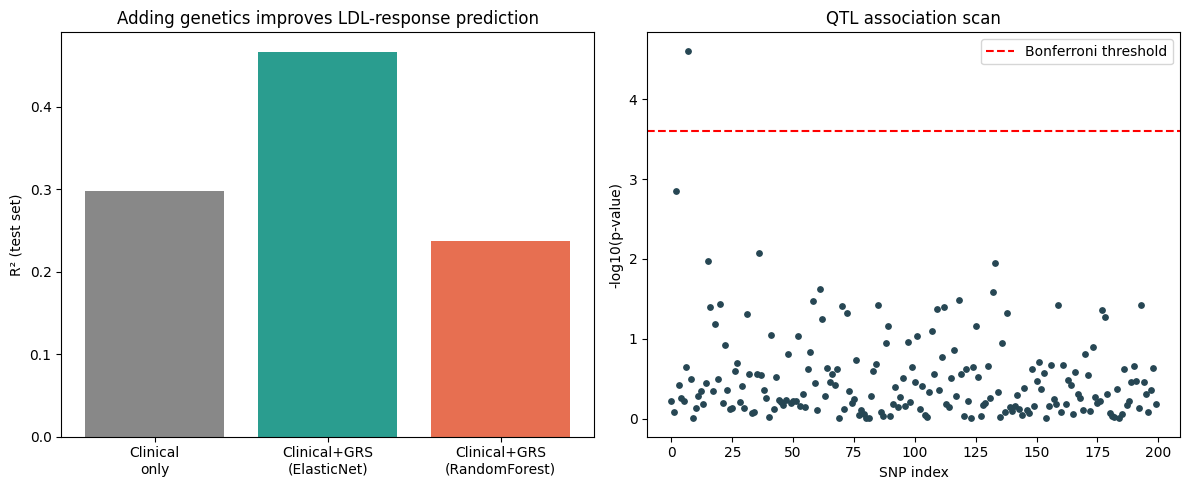

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Model comparison
models = ["Clinical\nonly", "Clinical+GRS\n(ElasticNet)", "Clinical+GRS\n(RandomForest)"]
r2_scores = [0.298, 0.467, 0.237]
axes[0].bar(models, r2_scores, color=["#888", "#2a9d8f", "#e76f51"])
axes[0].set_ylabel("R² (test set)")
axes[0].set_title("Adding genetics improves LDL-response prediction")

# Plot 2: QTL Manhattan-style plot
axes[1].scatter(range(len(qtl_results)), -np.log10(qtl_results.sort_values("snp")["pvalue"]), s=15, color="#264653")
axes[1].axhline(-np.log10(0.05/200), color="red", linestyle="--", label="Bonferroni threshold")
axes[1].set_xlabel("SNP index")
axes[1].set_ylabel("-log10(p-value)")
axes[1].set_title("QTL association scan")
axes[1].legend()

plt.tight_layout()
plt.savefig("model_comparison_and_qtl.png", dpi=150)
plt.show()